# <font color="steelblue">180. Variables aleatorias discretas</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** Las variables aleatorias son conceptos fundamentales en estadística y probabilidad, que representan eventos inciertos o aleatorios. Las variables aleatorias pueden ser discretas (toman valores aislados) o continuas (toman valores en un rango continuo).

Las distribuciones de probabilidad describen la probabilidad de que ocurran diferentes valores de una variable aleatoria. Cada tipo de distribución de probabilidad tiene sus propias características y aplicaciones en diferentes campos.

La distribución de Bernoulli es una distribución de probabilidad discreta que modela el resultado de un experimento con solo dos posibles resultados: éxito o fracaso. Por ejemplo, el resultado de lanzar una moneda puede ser un éxito si sale cara o un fracaso si sale cruz.

La distribución binomial es una distribución de probabilidad discreta que modela el número de éxitos en un número fijo de ensayos independientes, cada uno con la misma probabilidad de éxito. Por ejemplo, el número de caras en 10 lanzamientos de una moneda.

La distribución de Poisson es una distribución de probabilidad discreta que modela el número de eventos raros que ocurren en un intervalo de tiempo o espacio fijo. Por ejemplo, el número de accidentes en un cruce en un día.

La distribución geométrica es una distribución de probabilidad discreta que modela el número de ensayos necesarios para obtener el primer éxito en una secuencia de ensayos independientes, cada uno con la misma probabilidad de éxito. Por ejemplo, el número de veces que se lanza una moneda antes de obtener la primera cara.

## <font color='steelblue'> Objetivos de aprendizaje

* Identificar y distinguir entre diferentes tipos de variables aleatorias, así como para comprender su naturaleza y aplicación en problemas de probabilidad.

* Conocer las distribuciones de probabilidad para las variables aleatorias discretas.

* Reconocer y saber diferencias las distribuciones de: Bernoulli, Binomial, de Poisson y Geométrica en problemas de probabilidad, así como entender sus diferentes aplicaciones y las situaciones en las que se utilizan.

## <font color='steelblue'> Contenidos </font>

1. Variables aleatorias discretas
1. Distribución de Bernoulli
1. Distribución Binomial
1. Distribución de Poisson
1. Distribución Geométrica

In [ ]:
# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math                 # importamos módulo para cáculos matemáticos

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%config InlineBackend.figure_format = 'retina'

## <font color='steelblue'> 1. Variables aleatorias discretas

En general, si queremos analizar experimentos aleatorios, nos solemos centrar en datos numéricos de dichos experimentos. Como, por ejemplo, en un partido de baloncesto nos interesa el número de puntos, cuántos tiros se han hecho, el número de rebotes, asistencias, etc. Si consideramos todo lo ocurrido en un partido de baloncesto como un experimento aleatorio, cada uno de los resultados que hemos mencionado nos proporciona información sobre el resultado de dicho experimento y se consideran *variables aleatorias*. Por lo tanto, vamos a considerar las **variables aleatorias** como variables con *valores reales* cuyos valores vienen determinados por un experimento aleatorio. Un valor o un número *real* es cualquiera que está comprendido entre $-\infty$ y $+\infty$, y este conjunto de valores se representa como $\mathbb R$.

Vamos a ver otra definición para estas variables. Tenemos que $S$ es el espacio muestral de un experimento aleatorio. Los resultados pueden tener cualquier forma, como colores, letras o marca de ropa. Entenderemos por **variable aleatoria** cualquier función $X$ que convierta estos resultados en *números reales* y se expresa como $X: S \rightarrow \mathbb R$. Si tenemos un resultado dado, $s$, en nuestro experimento, sabemos que este estará incluido en $S$ ($s \in S$), por lo que para denotar el número real asociado utilizaremos la función $X$: $X(s) \in \mathbb R$.

Una **variable aleatoria** es una descripción del resultado de un experimento estadístico. Una de estas variables que solo pueda asumir un número finito o una secuencia contable de valores se dice que es **discreta**, pero si puede asumir cualquier valor de los *números reales* diremos que es **continua**. En este cuaderno vamos a centrarnos en las primeras, en las **variables aleatorias discretas**.

Imaginemos que estamos trabajando con el experimento aleatorio de lanzar una moneda al aire. Sabemos que el espacio muestral con los posibles resultados será $S = \{Cara (c), Cruz (x)\}$. En este caso, la función que creará la *variable aleatoria* será la que asigne un $0$ si sale cara y un $1$ si sale cruz. Esto se muestra de la siguiente forma:

$$
X(S) = \left\lbrace\begin{array}{c} 0,~si~s=Cara \\ 1,~si~s=Cruz \end{array}\right.
$$

Otro ejemplo de *variable aleatoria* puede ser la utilizada para el experimento aleatorio de lanzar dos dados y obtener los posibles resultados. Los números que haya en los dados al lanzarlos los denotaremos por la tupla $(n_1, n_2)$, y el espacio muestral que tendremos será el de los 6 posibles resultados: $S = \{1, 2, 3, 4, 5, 6\}$. El número total resultante (la suma de los números de cada dado) será una variable aleatoria $X$ dada por una función que nos proporciona la suma de los dos dados. Esto se expresa como:

$$
X((n_1, n_2)) = n_1 + n_2
$$

Como hemos visto, las *variables aleatorias* se expresarán con letras mayúsculas como $X$, $Y$ o $Z$. Como tenemos que una estas variables son una función, podemos hablar de su rango. El **rango** de una *variable aleatoria* $X$, expresado como $Rango(X)$ o $R_X$, es el conjunto de posibles valores de $X$. Utilizaremos la notación $X(S) \subseteq R_X$ para denotar este conjunto. Si volvemos a los ejemplos anteriores, para el lanzamiento de la moneda nos proporciona que $R_X = \{0, 1\}$, o bien $X(S) \in \{0, 1\}$. Por otro lado, para la suma de los resultados al lanzar dos dados: $R_X = \{2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12\}$, o bien $X(S) \in \{2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12\}$.

Veamos un ejemplo un poco más complejo que los anteriores. En vez de lanzar una vez una moneda, nuestro experimento aleatorio será el de lanzar 3 veces la moneda. Si ha salido cara lo representaremos con una $Ca$ y si ha sido cruz con $Cr$, por lo que nuestro espacio muestral será: $R = \{xxx, xxc, xcx, cxx, xcc, cxc, ccx, ccc\}$. Vamos a contar el número de caras que se obtienen ($c$) y utilizaremos la función $X: S \in R$, con $s \in S$, para devolvernos el número de caras, $X(s)$, como *variable aleatoria*. Esta función se aplica como:

* $X(xxx) \rightarrow 0$;
* $X(xxc) \rightarrow 1$;
* $X(xcx) \rightarrow 1$;
* $X(cxx) \rightarrow 1$;
* $X(xcc) \rightarrow 2$;
* $X(cxc) \rightarrow 2$;
* $X(ccx) \rightarrow 2$;
* $X(xxx) \rightarrow 3$.

En este caso, el *rango* de la *variable aleatoria* será $R_X = \{0, 1, 2, 3\}$ o $X(S) \in \{0, 1, 2, 3\}$.

Imaginemos ahora que tenemos la *variable aleatoria* $Y$, que emplea una función para devolvernos un $1$ si los 3 lanzamientos son iguales o un $0$ si al menos hay 1 lanzamiento diferente. Por ejemplo: $Y(xxx) = 1$ e $Y(xcx) = 0$. El *rango* de esta nueva *variable aleatoria* es diferente, ya que en este caso será: $R_Y = \{0, 1\}$ o $Y(S) \in \{0, 1\}$.

Todas estas *variables aleatorias* que estamos viendo son *discretas*, ya que se encuentran en un conjunto finito y su rango es contable. Aunque los posibles resultados del espacio muestral no sean números enteros, mientras el conjunto sea finito, no importa. Por ejemplo, la variable $X(S) = \{0, 0.2, 0.4, 0.6, 0.8\}$ también es *discreta*. El intervalo $[1, 3]$ no corresponderá a una *variable aleatoria discreta*, ya que entre el $1$ y el $3$ hay infinitos valores reales ($\mathbb R$) posibles.

Una variable aleatoria discreta queda plenamente identificada o determinada al especificar todos sus valores posibles y la probabilidad asociada a cada uno de ellos. Eso significa que debemos conocer todos los posibles resultados de la variable aleatoria X, $(x_1, x_2, …,x_n)$ y las correspondientes probabilidades:

$$P(X = x_1), P(X = x_2),..., P(X = x_n)$$

En el ejemplo de la moneda si $X$ denota el número de caras tendríamos:

$$P(X = 0) = 1/8, P(X = 1) = 3/8, P(X = 2) = 3/8, P(X = 3) = 1/8$$


### <font color='steelblue'> Función de masa de probabilidad

La función de probabilidad, denotada por $P(x)$, proporciona la probabilidad de que la variable aleatoria $X$ tome cada uno de los posibles resultados, $x$,  de la variable aleatoria, es decir:

$$P_X(x) = P(X = x)$$

Las principales características de la función de probabilidad son:

* $0 \leq P_X(x) \leq 1$, para toda $x$

* $\sum_{x} P_X(x) = 1$

En muchas ocasiones la función de probabilidad se suele representar mediante un gráfico de barras para comprender mejor el comportamiento de la variable aleatoria estudiada.


Podemos rerpesentar la función de masa de probabildiad correspondiente a ejemplo  con el código siguiente:

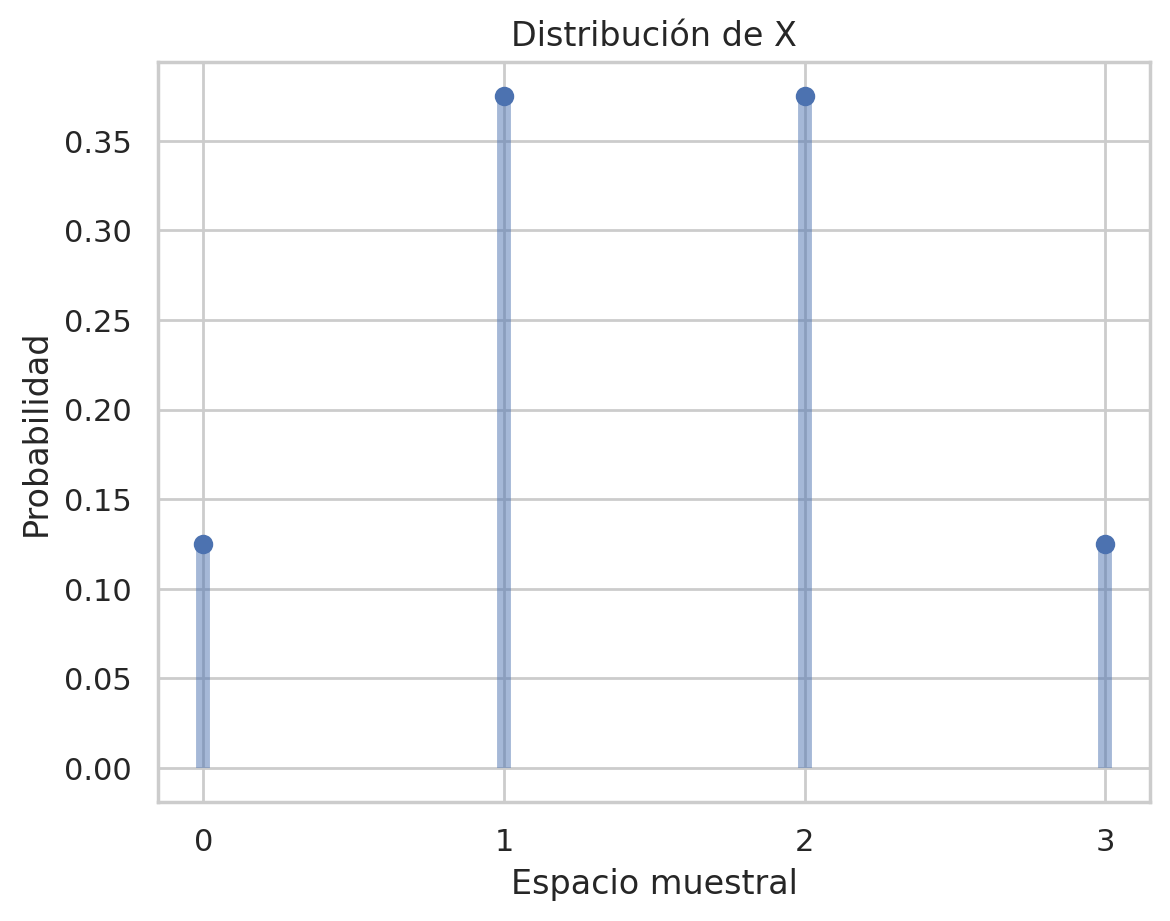

In [ ]:
# Gráfico de la función de masa de probabilidad
sns.set_theme(style="whitegrid")
# Espacio muestral y probabilidades de cada uno de ellos
x = [0, 1, 2, 3]
fmp = [1/8,3/8,3/8,1/8]

# Pintamos los puntos con x y la función de masa de probabilidad
plt.plot(x, fmp, 'bo');
# Dibujamos las líneas verticales correspondientes con sus caractarísticas
plt.vlines(x, 0, fmp, colors='b', lw=5, alpha=0.5);
# Ponemos un título
plt.title('Función de masa de probabilidad')
# Ponemos etiquetas a los ejes x e y
plt.xticks(x)
plt.ylabel('Probabilidad')
plt.xlabel('Espacio muestral')
plt.show()

### <font color='steelblue'> Función de distribución

La función de distribución, denotada por $F(x)$, proporciona la probabilidad de que la variable aleatoria $X$ tome todos los valores menores o iguales al valor $x$, es decir:

$$F(x) = P(X \leq x)$$

De nuevo, se suele representar la función de distribución mediante un gráfico de barras para conocer como se acumula la probabilidad cuando nos movemos por los distintos valores de la variable. A través de la función de probabilidad y distribución resulta sencillo realizar cualquier cálculo probabilístico relacionado con la variable de interés.


Podemos rerpesenatr también la función de distribución asociada a nuestro ejemplo.

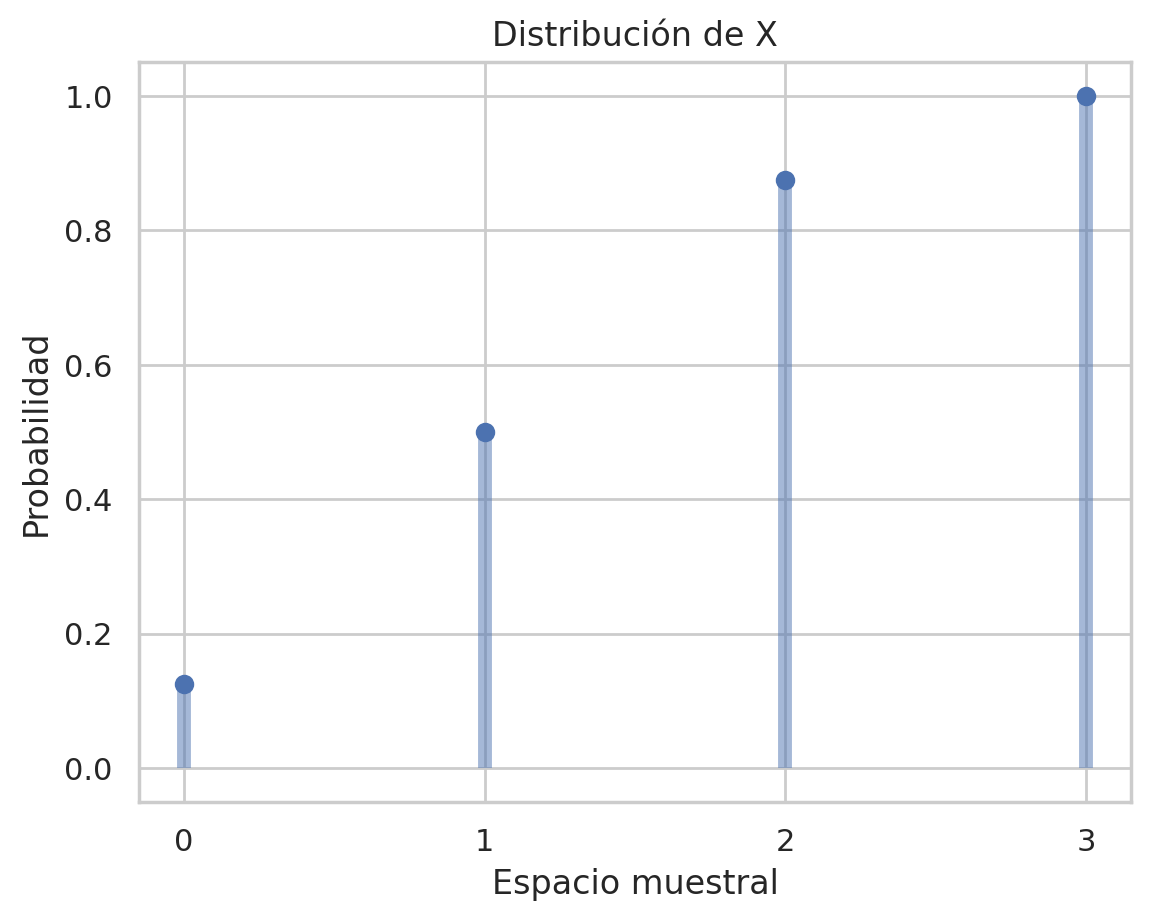

In [ ]:
# Espacio muestral y probabilidades de cada uno de ellos
x = [0, 1, 2, 3]
fmp = [1/8,3/8,3/8,1/8]
# Función de distribución
fdist = [sum(fmp[:(l+1)]) for l in range(len(fmp))]

# Pintamos los puntos con x y la función de distribución
plt.plot(x, fdist, 'bo');
# Dibujamos las líneas verticales correspondientes con sus caractarísticas
plt.vlines(x, 0, fdist, colors='b', lw=5, alpha=0.5);
# Ponemos un título
plt.title('Función de Distribución')
# Ponemos etiquetas a los ejes x e y
plt.xticks(x)
plt.ylabel('Probabilidad')
plt.xlabel('Espacio muestral')
plt.show()

### <font color='steelblue'> Cálculo de probabilidades

En este punto mostramos como utilizar la función de probabilidad y de distribución para el cálculo de cualquier probabilidad asociada con una variable de tipo discreto. En la tabla siguiente se muestran las diferentes situaciones de cálculo que podemos plantear. Denotamos por x el valor o categoría de la variable que deseamos evaluar, por $x-1$ a la categoría justo por debajo de $x$, y por $x+1$ a la categoría justo por encima de $x$:


| Situación| Calculo|
|---------|----------|
|P(X<=a)| F(a) |
|P(X>=a)| 1-F(a-1)|
|P(X<a)| F(a-1)|
|P(X>a)| 1-F(a)|
|P(a<X<b)| F(b-1)-F(a)|
|P(a<=X<b)| F(b-1)-F(a-1)|
|P(a<X<=b)| F(b)-F(a)|
|P(a<=X<=b)| F(b)-F(a-1)|





**Ejemplo.** Tenemos que la *variable aleatoria discreta* $X$ tiene la siguiente *función de masa de probabilidad*:

$$
P(x) = \left\lbrace\begin{array}{l} 0.1,~~si~x=0.2 \\ 0.2,~~si~x=0.4 \\ 0.2,~~si~x=0.5 \\ 0.3,~~si~x=0.8 \\ 0.2,~~si~x=1 \\ 0,~~~~en~otro~caso \end{array}\right.
$$

Em primer lugar vamos a representar la función de masa de probabilidad y la función de distribución correspondiente a esta variable aleatoria, para más tarde realizar diferentes calculos de probabilidad. Como los valores del espacio muestral $S =\{0.2, 0.4, 0.5, 0.8, 1\}$ no están igualmente espaciados debemos modificar algo los gráficos para representar adecuadamente ambas funciones.



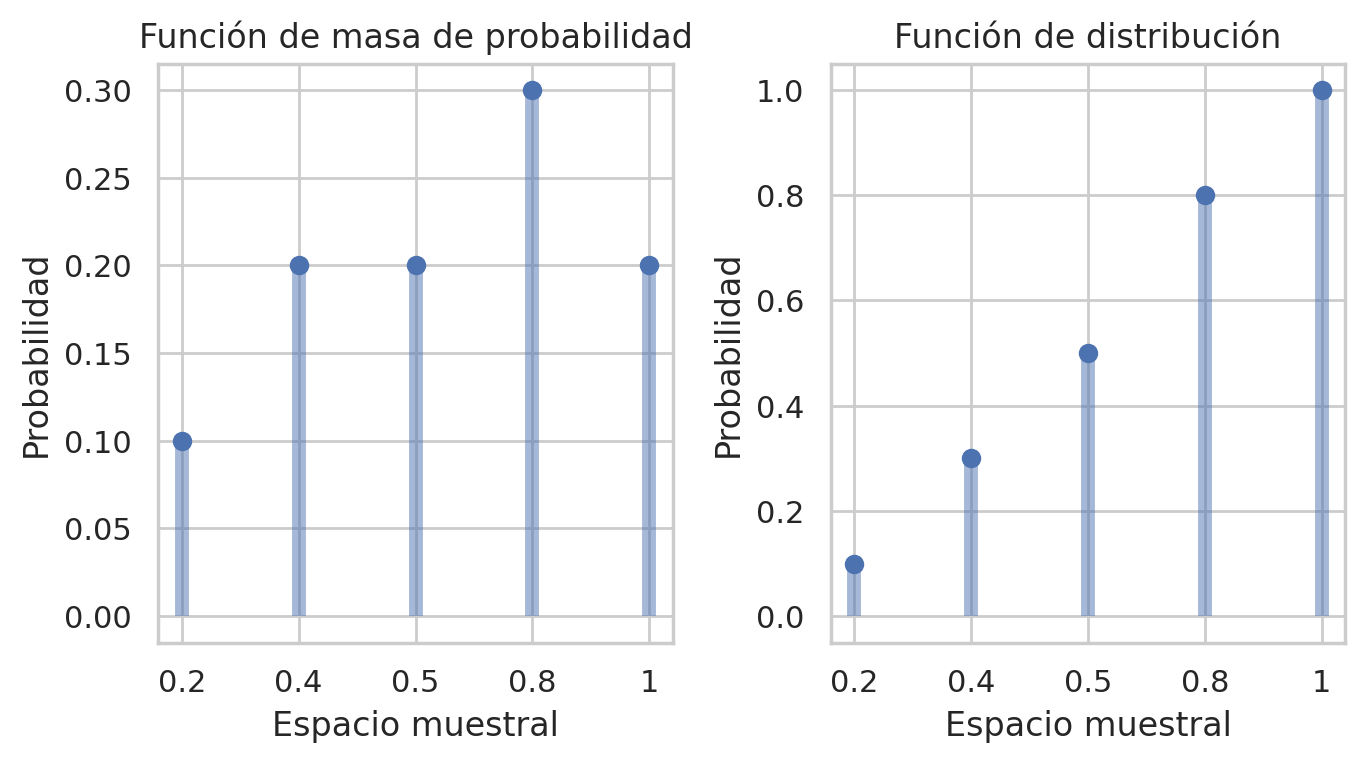

In [ ]:
# Espacio muestral y probabilidades de cada uno de ellos
x = [0.2, 0.4, 0.5, 0.8, 1]
pos = np.arange(len(x))
fmp = [0.1, 0.2, 0.2, 0.3, 0.2]
# Función de distribución
fdist = [sum(fmp[:(l+1)]) for l in range(len(fmp))]

fig, ax = plt.subplots(1, 2, figsize=(7, 4))

# Pintamos los puntos con x y la función de masa de probabilidad
ax[0].plot(pos, fmp, 'bo');
# Dibujamos las líneas verticales correspondientes con sus caractarísticas
ax[0].vlines(pos, 0, fmp, colors='b', lw=5, alpha=0.5);
# Ponemos un título
ax[0].set_title('Función de masa de probabilidad')
# Ponemos etiquetas a los ejes x e y
ax[0].set_xticks(pos, labels=x)
ax[0].set_ylabel('Probabilidad')
ax[0].set_xlabel('Espacio muestral')

#### Función de distribución
# Pintamos los puntos con x y la función de distribución
ax[1].plot(pos, fdist, 'bo');
# Dibujamos las líneas verticales correspondientes con sus caractarísticas
ax[1].vlines(pos, 0, fdist, colors='b', lw=5, alpha=0.5);
# Ponemos un título
ax[1].set_title('Función de distribución')
# Ponemos etiquetas a los ejes x e y
ax[1].set_xticks(pos, labels=x)
ax[1].set_ylabel('Probabilidad')
ax[1].set_xlabel('Espacio muestral')

plt.tight_layout()

Antes de comenzar con als probabilidades vamos a generar una dataframe donde almacenamos los valores x, la función de masa de probabilidad y la función de distribución.

In [ ]:
datos = pd.DataFrame({"x":x, "Fmp":fmp, "Fdist":fdist})
datos

,x,Fmp,Fdist
0,0.2,0.1,0.1
1,0.4,0.2,0.3
2,0.5,0.2,0.5
3,0.8,0.3,0.8
4,1.0,0.2,1.0


Ahora estamos interesados en las probabilidades siguientes. Probabilidad de que X sea menor o igual a 0.5. Debemos calcular la probabilidad $P(X \leq 0.5)$. Esto ocurrirá solo cuando $X$ valga $0.2$, $0.4$ o $0.5$. Con esto tendremos

$$
P(X \leq 0.5) = P(X \in \{0.2, 0.4, 0.5\}) = P(X = 0.2) + P(X = 0.4) + P(X = 0.5) = 0.1 + 0.2 + 0.2 = 0.5
$$

Podemos hacerlo con código de forma directa

In [ ]:
# Utilizando la función de masa de probabilidad
filtro = datos.x <= 0.5
sum(datos.Fmp[filtro])

0.5
2    0.5
Name: Fdist, dtype: float64


La siguiente probabilidad que vamos a calcular es la de que el valor de $X$ se encuentre entre $0.25$ y $0.75$ sin incluirlos, $P(0.25 \lt X \lt 0.75)$. De forma similar a antes, los valores de $X$ que cumplen esta condición son $0.4$ y $0.5$, por lo tanto, tendremos que:

$$
P(0.25 \lt X \lt 0.75) = P(X \in \{0.4, 0.5\}) = P(X = 0.4) + P(X = 0.5) = 0.2 + 0.2 = 0.4
$$

Veamos el resultado con nuestro código:

In [ ]:
# Utilizando la función de masa de probabilidad
filtro = ((datos.x > 0.25) & (datos.x < 0.75))
sum(datos.Fmp[filtro])

0.4


Por último, vamos a ver cómo calcular una *probabilidad condicionada*, queremos encontrar la probabilidad de que $X = 0.2$ sabiendo que (dado que) $X \lt 0.6$. Para esto vamos a utilizar la fórmula correspondiente a esta probabilidad: $P(A|B) = \frac{P(A \cap B)}{P(B)}$. Sustituiremos por nuestros valores:

$$
P(X = 0.2|X \lt 0.6) = \frac{P(X=0.2 \cap X<0.6)}{P(X \lt 0.6)}
$$

Una vez tenemos esto, vamos a ver qué ocurrirá en el numerador y en el denominador. Arriba tenemos la probabilidad de que el valor de $X$ sea igual a $0.2$ **y** que sea menor que $0.6$, la única ocasión que se cumple esto es cuando $X = 0.2$. Para el denominador, se dará para los valores $X \in \{0.2, 0.4, 0.5\}$. Continuamos con nuestra ecuación:

$$
P(X = 0.2|X \lt 0.6) = \frac{P(X \in \{0.2\})}{P(X \in \{0.2, 0.4, 0.5\})} = \frac{P(X = 0.2)}{P(X = 0.2) + P(X = 0.4) + P(X = 0.5)} = \frac{0.1}{0.1 + 0.2 + 0.2} = 0.2
$$

Utilziamos ahora python para resolver la probabilidad

In [ ]:
# filtro para el numerador
filtro_num = ((datos.x == 0.2) & (datos.x < 0.6))
# filtro denominador
filtro_den = datos.x < 0.6
## probabildad condicionada
probabilidad = sum(datos.Fmp[filtro_num])/sum(datos.Fmp[filtro_den])
probabilidad

0.2

### <font color='steelblue'> Esperanza y varianza

La función de distribución de probabilidad de una variable aleatoria contiene exhaustivamente toda la información sobre la variable. Sin embargo, resulta conveniente resumir sus características principales con unos cuantos valores numéricos de forma similar a lo que hacíamos con los estudios descriptivos de una muestra. Entre estos están la esperanza y la varianza matemáticas.
Se define el valor esperado o esperanza matemática de una variable aleatoria discreta $X$, y se denota por $E(X)$, al valor promedio de $X$ atendiendo a su distribución de probabilidad, es decir, la media ponderada de los valores de $X$ tomando las $P(X=x)$ como ponderaciones, de forma que si la variable aleatoria puede tomar valores $x_1,x_2,...,x_k$ la esperanza se puede obtener mediante la expresión:

$$E(X) = \sum_{i=1}^k x_i P(X=x_i)$$

Se define la varianza matemática para dicha variable como el promedio ponderado de las diferencias al cuadrado observadas entre los valores de la variable y su esperanza, es decir:

$$V(X) = \sum_{i=1}^k (x_i-E(X))^2 P(X=x_i)$$

Tenemos expresiones similares a las de la media muestral y varianza muestral pero calculadas sobre todo el conjunto de valores posibles de la variable aleatoria y sólo sobre aquellos que observamos en la muestra. La mayor dificultad estriba en que debemos conocer completamente la distribución de probabilidad asociada, ya que sino resulta imposible realizar ninguno de los cálculos anteriores.


A continuación obtenemos el valor esperado y la varianza (y desviación típica) asociado conla distribución del último ejemplo.

In [ ]:
# Valor esperado
esperanza = sum(datos.x*datos.Fmp)
print("Esperanza: ", round(esperanza,3))
# Varianza
varianza = sum(((datos.x-esperanza)**2)*datos.Fmp)
print("Varianza: ", round(varianza,3))
# Desviación típica
print("DT: ", round(np.sqrt(varianza),3))

Esperanza:  0.64
Varianza:  0.068
DT:  0.262


## <font color='steelblue'> 2. Distribución de Bernoulli

Sobre las *variables aleatorias discretas* de *experimentos aleatorios* podemos aplicar diferentes *distribuciones de probabilidad* para modelar muchos modelos que ocurren en la vida real. Para ello aplicaremos de diferentes formas la *función de masa de probabilidad*.

Empezaremos viendo la más sencilla, la **distribución de Bernoulli**. Una *variable aleatoria de Bernoulli* solo podrá tomar dos valores, normalmente estos son 1 o 0. Esta variable modelo experimentos aleatorios que tienen solo dos resultados posibles, también se les conoce experimentos de éxito/fracaso, midiendo la probabilidad de éxito. Algunos ejemplos de este tipo son:

* El resultado de un examen es aprobado ($X=1$) o suspenso ($X=0$).
* Al lanzar una moneda podemos tener cara ($X=1$) o cruz ($X=0$).
* El sexo de un sujeto puede ser mujer ($X=1$) u hombre ($X=0$).

De manera formal, la *distribución de Bernoulli* se define como:

> **Definición.** Una *variable aleatoria* $X$ se le llama *de Bernoulli* con parámetro $p$, siendo representada por $X \sim Bernoulli(p)$, si su *función de masa de probabilidad* viene dada por: $$P(x) = \left\lbrace\begin{array}{l} p,~~~~~~~~~si~x=1 \\ 1-p,~~si~x=0 \\ 0,~~~~~~~~~en~otro~caso \end{array}\right.$$ para $0 \lt p \lt 1$.

Para esta dsitribución tenemos que el valor esperado y la desviación típica vienen dados por las expresiones:

$$E(X) = p$$

$$V(X) = p(1-p); DT(X)=\sqrt{p(1-p)}$$


Ahora bien, no siempre es tan fácil ver que una *variable aleatoria* sigue una *distribución de Bernoulli*. Imaginemos que estamos trabajando con el experimento aleatorio de lanzar un dado de 6 caras y apuntamos los resultados para definir nuestra *variable aleatoria*, estos están entre 1 y 6, es decir, no hay solo 2 posibles resultados y no seguiría esta *distribución*. Ahora bien, para nuestra *variable aleatoria discreta* vamos a considerar como éxito que el resultado sea par y como fracaso que sea impar. Aquí hemos transformado nuestra *variable* en una que sigue un *distribución de Bernoulli*. Podremos dar el valor $1$ a $X$ si el resultado del dado es $2$, $4$ o $6$ y tendrá el valor $0$ en caso contrario, cuando sea $1$, $3$ o $5$. Por lo tanto, en este caso, la probabilidad de éxito, $p$, será $0.5$, al igual que la de fracaso, $1-p$. Si queremos trabajar con una *variable aleatoria discreta* que siga esta *distribución* y de primeras no parece que lo haga, deberemos "transformar" los resultados para poder trabajar con ella.

Una vez hemos visto cómo funciona esta distribución, vamos a empezar a trabajar con el código de **Python** específico para ella. Primero de todo vamos a importar el módulo `stats` de la librería *SciPy*.

In [ ]:
# Importamos el módulo stats de scipy
from scipy import stats

La función que nos permite crear una varaible Bernouilli es `stats.bernouilli(p)`, donde `p` es la probabildiad de éxito del experimento. A partir de ella tenemos disponible:

* La función de masa de probabilidad con el método `pmf(x)`, donde $x$ es el valor que deseamos evaluar.
* La función de distribución acumulada con el método `cdf(k, p)` que se corresponde con $P(X \leq k)$ para una varaible bernouilli con probabilidad de éxito $p$.
* El valor esperado con el método `mean()` y la varianza con el método `var()`.
* Generador de valores aleatorios de la distribución con el método `rvs(n)`, donde `n` es el número de valores aletorios que deseamos generar, que en este caso solo serán 0 o 1 ya que son los poisble resultados de la variable aleatoria.

Veamos todos estos resultados aplicados sobre un ejemplo de una variable aleatoria Bernouilli con probabildiad de éxito igual a 0.25.


In [ ]:
# Fijamos la distribución
p = 0.25
# Creamos la variable aleatoria
X_bernoulli = stats.bernoulli(p)

Podemos obtener el espacio muestral de la variable aleatoria discreta considerada con:

In [ ]:
list(X_bernoulli.support())

[0, 1]

Obtenemos la función de masa de rpobabildiad y la representamos gráficamente pero para ello definimos una función que nos permitíra pintar la función de masa de probabildiad asociada a cualquier variable discreta su conocemos el espacio muestral y la probabilidades asociadas a cada uno de los elementos.

In [ ]:
def fmp_discreta(x,distx):
  '''
  Función que nos permite representar la función de masa de probabilidad
  de una variable aleatoria discreta

  Parámetros entrada:
  - x: valores del espacio muestral
  - distx: valores de la función de msas de probabilidada asociados a x

  Devuleve el gráfico de la función de masa de probabilidad
  '''
  # Pintamos los puntos con x y la función de masa de probabilidad
  plt.plot(x, distx, 'bo');
  # Dibujamos las líneas verticales correspondientes con sus caractarísticas
  plt.vlines(x, 0, distx, colors='b', lw=5, alpha=0.5);
  # Ponemos un título
  plt.title('Función de masa de probabilidad')
  # Ponemos etiquetas a los ejes x e y
  plt.xticks(x,  fontsize=8)
  plt.yticks(np.arange(0,1.05,0.05), fontsize=7)
  plt.ylabel('Probabilidad')
  plt.xlabel('Espacio muestral')
  plt.show()

Veamos el resultado

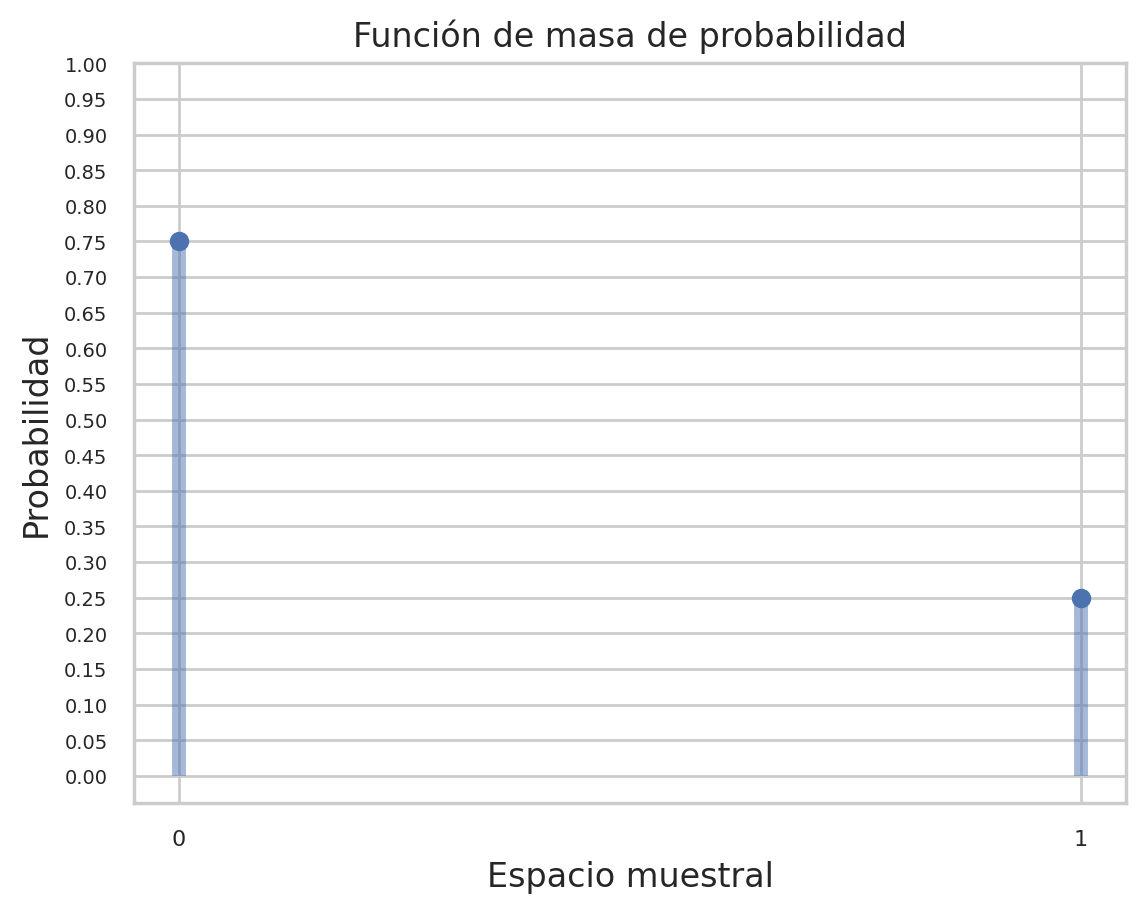

In [ ]:
# Espacio muestral y probabilidades de cada uno de ellos
x = list(X_bernoulli.support())
fmp = [X_bernoulli.pmf(k) for k in x]
# Gráfico
fmp_discreta(x,fmp)

Obtenemos ahora la esperanza, varianza y desviación típica de la variable aleatoria definida.

In [ ]:
# Media
print(f"La media de la variable X será: {round(X_bernoulli.mean(),4)}.")
# Varianza
print(f"La varianza de la variable X será: {round(X_bernoulli.var(),4)}.")
# Desviación típica
print(f"La desviación típica de la variable X será: {round(np.sqrt(X_bernoulli.var()),4)}.")

La media de la variable X será: 0.25.
La varianza de la variable X será: 0.1875.
La desviación típica de la variable X será: 0.433.


## <font color='steelblue'> 3. Distribución Binomial

Un experimento *Binomial* es aquel que repite $n$ veces un experimento de *Bernoulli*. Dicho esto, vamos a entrar más en profundidad. Tendremos un experimento **Binomial** si se cumplan las 4 siguientes condiciones:

* El experimento debe constar de $n$ ensayos finitos idénticos.
* Los ensayos serán de estilo *Bernoulli*: éxito/fracaso, es decir, se podrán obtener solo 2 resultados.
* La probabilidad de éxito, $p$, será la misma de un ensayo a otro.
* Los $n$ ensayos son independientes, es decir, el resultado de cualquier prueba no afectará al resultado de las demás.

Para darse este tipo de experimentos, se deberán cumplir **todas** ellas. Si definimos una *variable aleatoria discreta* $X$ como la suma de éxitos en los $n$ ensayos del *experimento binomial*, la *función de distribución de probabilidad* de dicha variable, se conoce como **distribución Binomial** y la expresamos como $X \sim Binomial(n,p)$.

El espacio muestral de esta variable será el conjunto $\{0, 1, 2, \ldots, n\}$, que se corresponde con el número de éxitos observados en los n experimentos.

> **Definición**. Una *variable aleatoria discreta* $X$ se dice que sigue una *distribución Binomial* con parámetros $n$ y $p$, representada por $X \sim Binomial(n, p)$, si su *función de masa de probabilidad* viene dada por: $$P(k) = \left\lbrace\begin{array}{l} \binom{n}{k}\cdot p^k \cdot (1-p)^{n-k},~~si~k=0, 1, 2, \ldots, n \\ 0,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~en~otro~caso \end{array}\right.$$ para $0 \lt p \lt 1$.

De esta forma tenemos que:

$$E(X) = np$$

$$V(X) = np(1-p); DT(X)=\sqrt{np(1-p)}$$


La *distribución Binomial* se utiliza con frecuencia para modelizar el número de aciertos en una muestra de tamaño $n$ extraída, **con** reemplazamiento, de una población de tamaño $N$. Deberemos tener en cuenta esto, ya que, si la extracción es realizada **sin** reemplazamiento, las probabilidades de elección variarán, por lo que no se cumplirán ni la tercera ni la cuarta condición para que sea *Binomial*. Sin embargo, si tenemos una población con una $N$ mucho mayor que la muestra $n$ que extraemos, sí se aproxima mucho a una *distribución Binomial*.

La función que nos permite crear una variable Binomial es `stats.binom(n,p)`, donde `n` es el número de experimentos y `p` es la probabildiad de éxito en cada uno de ellos. Una vez especificada la varaible aleatoria podemos obtener:

* La función de masa de probabilidad con el método `pmf(x)`, que se corresponde con $P(X = k)$ para una variable $Binomial(n, p)$.
* La función de distribución acumulada con el método `cdf(k)` que se corresponde con $P(X \leq k)$ para una variable $Binomial(n, p)$.
* El valor esperado con el método `mean()` y la varianza con el método `var()`.
* Generador de valores aleatorios de la distribución con el método `rvs(nsim)`,que genera $nsim$ valores aleatorios de una distribución $Binomial(n, p)$

Veamos todos estos resultados sobre algunos ejemplos.


**Ejemplo.** En una fábrica se seleccionan artículos al azar para hacer un control de calidad, sabiendo que la probabilidad de encontrar un artículo defectuoso es del $1\%$. Se quiere hallar la probabilidad de encontrar solo $1$ artículo defectuoso si escogemos una muestra aleatoria de 15 artículos. El tamaño total de artículos fabricados ($N$) es muy elevado, ya que se fabrican muchos, y nuestra muestra ($n$) es pequeña, por lo que consideramos que este experimento se compone de $n$ ensayos *Bernoulli* independientes, por lo que resulta ser un experimento *Binomial*, en el que consideramos como éxito la selección de un artículo defectuoso. Por lo tanto, la probabilidad de éxito tendremos que es $p=0.01$, mientras que la probabilidad de fracaso es $1-p=1-0.01=0.99$. Con todo esto, ya podemos definir nuestra *variable aleatoria discreta Binomial* $X$ como el número de artículos defectuosos que hay en una muestra de tamaño $n$: $X \sim Binomial(15, 0.01)$.

Representamos la función de masa de probabildiad correspondiente a esta situación experimental, onteniedo el espacio muestral correspondiente

In [ ]:
np.arange(X_binomial.support()[0],X_binomial.support()[1]+1,1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

Obtenemos el gráfico

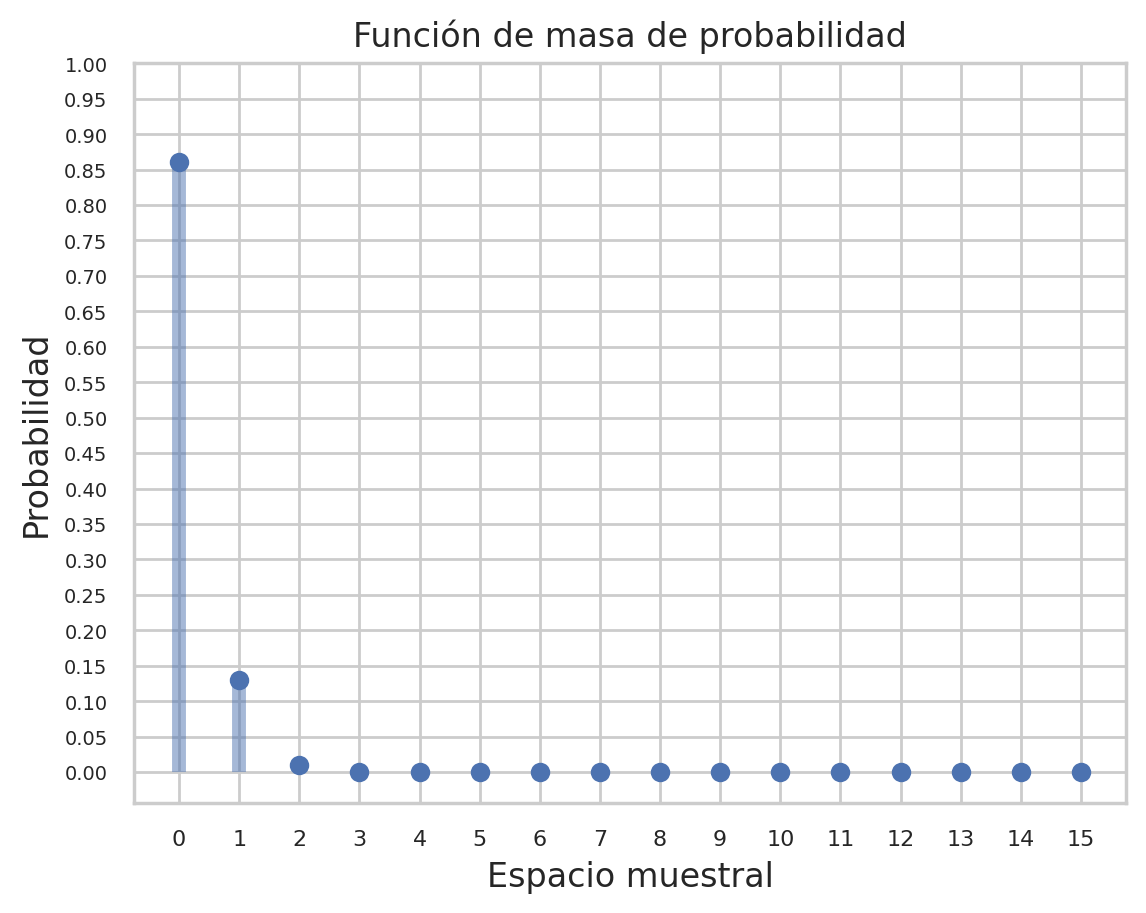

In [ ]:
# Tamaño de la muestra
n = 15
# Probabilidad de éxito
p = 0.01
# Creamos X como una variable aleatoria entera Binomial, con los parámetros correspondientes
X_binomial = stats.binom(n=n, p=p)

# Gráfico
# Espacio muestral y probabilidades de cada uno de ellos
x = np.arange(X_binomial.support()[0],X_binomial.support()[1]+1,1)
fmp = [X_binomial.pmf(k) for k in x]
# Gráfico
fmp_discreta(x,fmp)

Cuando nos dicen que se quiere hallar la probabilidad de encontrar $1$ artículo defectuoso en esta muestra, se nos está preguntando por la probabilidad $P(x=1)$, que podemos obtener directamente a partir de la función de masa de probabilidad.

In [ ]:
# Mostramos la probabilidad de que haya un artículo defectuoso en la muestra, k=1
print(round(X_binomial.pmf(k=1), 4))

0.1303


Estamos interesadoa ahora en saber la probabilidad de que haya $2$ artículos defectuosos como mucho de nuestra muestra de $15$. Esto lo expresamos como $P(x \leq 2)$, cuyo valor lo podemos obtener fácilmente con la función de distribución.

In [ ]:
# Probabilidad de haber como máximo 2 artículos defectuosos
print(round(X_binomial.cdf(x=2), 4))

0.9996


Ahora estamos interesados en la probabilidad de que hay menos de 4 éxitos, es decir, $P(X < 4)$, que por la reglas de cálculo antes expuestas para varaibles discretas es igual a $P(X \leq 3)$. Veamos el resultado:

In [ ]:
# Probabilidad de hay menos de 4 artículos defectuosos
print(round(X_binomial.cdf(x=3), 4))

1.0


Quremos conocer ahora la probabilidad de que en nuestra muestra haya 2 o más artículos defectuosos. La probabildiad de interés es $P(x \geq 2)$ que por las reglas de cáculo para variables aleatorias discretas es igual a $1 - P(x \leq 1)$.

In [ ]:
# Probabilidad de obtener 2 o más artículos defectuosos
print(round(1 - X_binomial.cdf(x=1), 4))

0.0096


Obtnemos ahora el número medio de defectos y su varaibilidad (en términos de la desviación típica).

In [ ]:
# Media
print(f"La media de la variable X será: {round(X_binomial.mean(),4)}")

# Varianza
print(f"La desviación típica de la variable X será: {round(np.sqrt(X_binomial.var()),4)}")

La media de la variable X será: 0.15
La desviación típica de la variable X será: 0.3854


## <font color='steelblue'> 4. Distribución de Poisson

La **distribución de Poisson** es una de las distribuciones de probabilidad que más se utilizan. Suele emplearse en situaciones en las que contamos cuántos sucesos ocurren en un intervalo de tiempo o espacio. Veamos un pequeño ejemplo de dónde utilizaríamos esta nueva distribución: estamos contando el número de clientes que visita una tienda determinada de 13:00 a 14:00. Según la información que tenemos de días anteriores, sabemos que, de media, visitan la tienda 15 clientes. Como es una media, este valor podrá ser mayor unos días y menor en otros. En este caso, tendremos nuestra *variable aleatoria discreta* $X$, que indicará el número de clientes como una *variable aleatoria de Poisson* con parámetro $\lambda = 15$. En este caso, el parámetro que vamos a utilizar será el *lambda* ($\lambda$). A continuación, vamos a definir las *variables aleatorias de Poisson* y su *función de masa de probabilidad*:

> **Definición.** Una *variable aleatoria discreta* $X$ se dice que sigue una *distribución de Poisson* con parámetro $\lambda$ (*lambda*), representada por $X \sim Poisson(\lambda)$, si su espacio muestral es \{0 ,1, 2, \ldots\}$ y su *función de masa de probabilidad* viene dada por: $$P(x=k) = \left\lbrace\begin{array}{l} \frac{e^{-\lambda} \cdot \lambda^k}{k!},\text{si k} \in R_X \\ 0,\text{en otro caso} \end{array}\right.$$

A continuación, se proporciona un gráfico interactivo para ver cómo influye el valor medio de eventos que ocurren en el intervalo de tiempo o espacio que estamos estudiando, $\lambda$. Podemos observar dos cosas con la variación de este parámetro:

* A mayor número de sucesos (mayor $\lambda$), las probabilidades de que ocurran $k$ sucesos irá disminuyendo, y viceversa.

* A mayor número de sucesos (mayor $\lambda$), la curva del gráfico (de las probabilidades de los sucesos) se irá desplazando hacia la derecha, y viceversa.

De esta forma tenemos que:

$$E(X) = \lambda$$

$$V(X) = \lambda; DT(X)=\sqrt{\lambda}$$

En este caso podemos tener problemas a la hora de representra gráficamente la distribución de poissson porque el espacio muestral es infinito. PAra poder hacerlo se toma como valor superior uno en el que la función de masa de probabilidad sea cero.


La función que nos permite crear una variable Poisson es `stats.poisson(l)`, donde `l` es la media por unidad de tiempo de la distribución de poisson. Una vez especificada la variable aleatoria podemos obtener:

* La función de masa de probabilidad con el método `pmf(x)` que se corresponde con $P(X = k)$ para una variable $Poisson(\lambda)$.
* La función de distribución acumulada con el método `cdf(k)` que se corresponde con $P(X \leq k)$ para una variable $Poisson(\lambda)$.
* El valor esperado con el método `mean()` y la varianza con el método `var()`.
* Generador de valores aleatorios de la distribución con el método `rvs(nsim)`,que genera $nsim$ valores aleatorios de una distribución $Poisson(\lambda)$.

Veamos todos estos resultados sobre algunos ejemplos.



**Ejemplo.** El número de correos electrónicos que recibe una empresa en un día laborable puede modelarse mediante una *distribución de Poisson*, siendo la media de $0.2$ correos por minuto. Se nos pide:

* La probabilidad de que no reciba ningún correo electrónico en un intervalo de 5 minutos.

* La probabilidad de que reciban más de 3 correos electrónicos en un intervalo de 10 minutos.

En ambos casos, deberemos tener en cuenta cuánto valdrá el parámetro $\lambda$, ya que será diferente por medir intervalos de tiempo distintos. Empecemos por el primero, tendremos la variable aleatoria $X_1$ que es el número de correos electrónicos que recibe la empresa en un intervalo 5 minutos. Para el parámetro $\lambda$, debemos tener en cuenta el dato que nos dan de $0,2$ *emails*/minuto y multiplicarlo por el intervalo de tiempo que nos dan, así tendremos el número medio de correos electrónicos que recibe la empresa en 5 minutos: $\lambda = 0,2\cdot5 = 1$, con esto tenemos que esta empresa recibe en un intervalo de 5 minutos, una media de 1 correo electrónico.

En la segunda situación com el periodo de tiempo es de 10 minutos tendremos que la varaible aleatoria $X_2$ que es el número de correos electrónicos en un intervalo de 10 minutos es Poisson con media igual a $10*0.2 = 2$.

Veamos como obtener las probabildiades deseadas.

En el pirmer caso estamos interesados en la probabilidad $P(X_1 = 0)$ con $X_1 \sim Poisson(1)$. Utilizamos la función de masa de probabilidad.

In [ ]:
# Asignamos el valor a nuestro parámetro
lambda1 = 1
# Generamos el modelo de la distribución de Poisson con lambda1
X1_poisson = stats.poisson(lambda1)
# Probabilidad de no recibir ningún correo en un intervalo de 5 minutos
print(round(X1_poisson.pmf(k=0), 4))

0.3679


En la segunda situación estamos interesados en $P(X_2 > 3)$ con  $X_2 \sim Poisson(2)$. Dicha probabilidad es igual a $1 - P(X_2 \leq 3)$, que se puede obtener con la función de distribución.

In [ ]:
# Asignamos el nuevo valor a nuestro parámetro
lambda2 = 2
# Generamos el modelo de la distribución de Poisson con lambda2
X2_poisson = stats.poisson(lambda2)
# Probabilidad de recibir más de 3 correos en un intervalo de 10 minutos
print(round(1 - X2_poisson.cdf(x=3), 4))

0.1429


En las dos situaciones experimentales el número medio de correos electrónicos recibidos y su variaanza vienen dados por $\lambda=1$ y $\lambda=2$ respectivamente.

Ahora bien, la *distribución de Poisson* guarda una relación con algunas *distribuciones Binomiales* especiales, es decir, la *distribución de Poisson* puede verse como un límite de la *distribución Binomial*. Esto ocurrirá en el caso en el que si tenemos que $X \sim Binomial(n, p)$, su tamaño de la muestra ($n$) será muy grande y la probabilidad de éxito ($p$) es muy pequeña. Cuando se da este caso, podemos transformar nuestra variable $X \sim Binomial(n, p)$ en $X \sim Poisson(\lambda)$, siendo el parámetro $\lambda = n \cdot p$.

A continuación, hay un gráfico interactivo en el cual podemos cambiar el tamaño de la muestra con la que trabajemos ($n$) y la probabilidad de éxito ($p$), que son parámetros de una *distribución Binomial*. Con estos valores calcularemos un parámetro $\lambda$ para una *distribución de Poisson* ($\lambda = n \cdot p$). Puedes ir jugando con estos valores para ver cómo cambia el gráfico:

* Si el valor de $n$ es muy grande y el de $p$ muy pequeño, los gráficos de ambas distribuciones serán casi idénticos.

* Si solo disminuimos el tamaño de la muestra ($n$), no habrá mucha diferencia entre los gráficos.

* Si aumentamos la probabilidad de éxito ($p$), las distribuciones empezarán a diferenciarse más, siendo la *distribución de Poisson* más alta y más estrecha que la *distribución Binomial*.

## <font color='steelblue'> 5. Distribución Geométrica

La última *distribución* para *variables aleatorias discretas* que veremos es la **distribución Geométrica**. Esta *distribución* se basa en experimentos aleatorios donde se cuenta el número de veces que se repite hasta conseguir un éxito. Pongamos un ejemplo: en el experimento de lanzar una moneda, lo repetiremos hasta obtener una cara. De esta forma, tenemos que la *variable aleatoria* $X$ será el número total de lanzamientos que se realizan en este experimento. Se puede pensar en la *distribución Geométrica* como la repetición de ensayos de tipo *Bernoulli* independientes hasta que se da el primer éxito. En esta distribución tendremos solo el parámetro $p$, que es la probabilidad de éxito. El caso de fracaso, o no éxito, es el opuesto: $1 - p$, y lo contaremos $k - 1$ veces, siendo $k$ el intento en el que se consigue el éxito. De esta forma, podemos definir cómo es una *variable aleatoria Geométrica* y su *función de masa de probabilidad*:

> **Definición.** Una *variable aleatoria discreta* $X$ se dice que sigue un *distribución Geométrica* con parámetro $p$ (probabilidad de éxito), expresada como $X \sim Geometrica(p)$, si su *función de masa de probabilidad* viene dada por: $$P(x=k) = \left\lbrace\begin{array}{l} p \cdot (1-p)^{k-1},~~~~si~k=1, 2, 3, \ldots, n \\ 0,~~~~~~~~~~~~~~~~~~~~~~~~en~otro~caso \end{array}\right.$$ para $0 \lt p \lt 1$.

Fíjate bien en que el rango de la $k$ empieza en $1$ y no en $0$, esto es así porque es imposible observar un éxito en el intento 0, es decir sin haber realizado el experimento.

Para esta variable aleatoria tenemos que:

$$E(X) = \frac{1-p}{p}$$

$$V(X) = \frac{1-p}{p^2}; DT(X) = \sqrt{V(X)}$$

La función que nos permite crear una variable Geométrica es `stats.geom(p)` donde `p` es la probabildiad de éxito. Una vez especificada la variable aleatoria podemos obtener:

* La función de masa de probabilidad con el método `pmf(x)` que se corresponde con $P(X = k)$ para una variable $Geometrica(p)$.
* La función de distribución acumulada con el método `cdf(k)` que se corresponde con $P(X \leq k)$ para una variable $Geometrica(p)$.
* El valor esperado con el método `mean()` y la varianza con el método `var()`.
* Generador de valores aleatorios de la distribución con el método `rvs(nsim)`,que genera $nsim$ valores aleatorios de una distribución $Geometrica(p)$.

Veamos todos estos resultados sobre algunos ejemplos.

**Ejemplo.** Tenemos el experimento de lanzar un moneda y ver cuántos tardamos en observar que sale cara. Se busca:

* La probabilidad de obtener una cara en la tercera tirada.
* La probabilidad de obtener una cara a partir del tercer lanzamiento.

Antes de empezar, vamos a declarar nuestra *variable aleatoria* $X$ como el número de intentos que realizamos lanzando la moneda hasta obtener una cara. Como la probabilidad de obtener una cara al lanzar una moneda es del $50\%$, tendremos que: $X \sim Geometrica(0.5)$. En este caso la probabilidad que se nos pide es $P(X=3)$ que se obtiene con la función de masa de probabilidad.

In [ ]:
# Asignamos el valor a nuestro parámetro
p = 0.5
# Generamos el modelo de la distribución Geométrica con p
X_geom = stats.geom(p)
# Probabilidad de obtener una cara en la tercera tirada
print(round(X_geom.pmf(k=3), 4))

0.125


En el segundo caso la probabilidad que deberemos calcular es la correspondiente a $P_X(x \geq 4)$, ya que queremos obtener la probabilidad de sacar una cara a partir del tercer lanzamiento (contando ese ya). Dicha probabildaid es igual a
$1 - P_X(x \leq 3)$ que se puede obteenr a partir de la función de distribución.

In [ ]:
# Probabilidad de obtener una cara a partir del tercer lanzamiento
print(round(1 - X_geom.cdf(x=3), 4))

0.25
